# Cell 1：Imports 与路径配置

In [1]:
# Cell 1: imports & config
import os, sys, math, pickle
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# interactive widgets
try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output
    _HAS_WIDGETS = True
except Exception:
    _HAS_WIDGETS = False

# ensure repo root is on path (notebook in notebooks/)
repo_root = Path('..').resolve()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

# import project modules
from src.geometry import Cylinder, cylinder_surface_distance, segment_plane_distance_to_x_plane
from src.truncation import split_cylinder_by_box
from src.connectivity import build_connectivity

# Data paths (adjust if your structure differs)
out_dir = Path(repo_root) / 'results' / 'outputs'
samples_dir = out_dir / 'samples'
mc_csv = out_dir / 'monte_carlo_results.csv'             # coarse MC or scan CSV
coarse_csv = out_dir / 'find_min_f_auto_coarse.csv'      # coarse results if exists
final_csv = out_dir / 'find_min_f_auto_final.csv'       # adapt if you have different name
hp_summary = out_dir / 'high_precision_f0p001000_summary.csv'  # example
print("Paths:", "out_dir=", out_dir, "samples_dir=", samples_dir)

Paths: out_dir= F:\数模专用\2026_HuaShuCup_Problem_A\results\outputs samples_dir= F:\数模专用\2026_HuaShuCup_Problem_A\results\outputs\samples


# Cell 2：

诊断当前 sample / segments 结构（检查端点是否越界、segment 数量、左右接触 id、同 id 同时接触左右等）

In [8]:
# Cell 2: diagnostics - check segments / samples and truncation/wrapping correctness
L = 10000.0  # use same L as simulation
half = L/2.0

def check_segments_in_box(segments, L):
    half = L/2.0
    out_of_box = []
    for i,s in enumerate(segments):
        p0 = np.asarray(s.p0); p1 = np.asarray(s.p1)
        if np.any(p0 < -half - 1e-6) or np.any(p0 > half + 1e-6) or np.any(p1 < -half - 1e-6) or np.any(p1 > half + 1e-6):
            out_of_box.append((i, s.id, p0, p1))
    return out_of_box

# list sample pickles if any
if samples_dir.exists():
    picks = sorted([p for p in samples_dir.glob('*.pkl')])
    print(f"Found {len(picks)} sample pickles (first 10):", [p.name for p in picks[:10]])
else:
    picks = []
    print("No samples dir found at", samples_dir)

# If at least one sample exists, inspect first
if picks:
    p0 = picks[0]
    print("Inspecting:", p0)
    with open(p0, 'rb') as f:
        obj = pickle.load(f)
    segments = obj.get('segments') or []
    print("Loaded segments:", len(segments))
    # check coords in box
    oob = check_segments_in_box(segments, L)
    print("Segments with endpoints outside box (should be 0):", len(oob))
    if len(oob) > 0:
        for entry in oob[:5]:
            idx, sid, p0_e, p1_e = entry
            print(f" seg_idx={idx}, id={sid}, p0={p0_e}, p1={p1_e}")
    # left/right touching ids
    left_ids=set(); right_ids=set()
    for i,s in enumerate(segments):
        d_left = segment_plane_distance_to_x_plane(s.p0, s.p1, -half)
        surf_left = max(0.0, d_left - s.r)
        if surf_left <= 1.8 + 1e-9:
            left_ids.add(s.id)
        d_right = segment_plane_distance_to_x_plane(s.p0, s.p1, half)
        surf_right = max(0.0, d_right - s.r)
        if surf_right <= 1.8 + 1e-9:
            right_ids.add(s.id)
    print("left touching ids:", len(left_ids), " right touching ids:", len(right_ids), " both:", len(left_ids & right_ids))
else:
    print("No sample pickles to inspect. If you expect samples, run high-precision verify first.")

Found 10 sample pickles (first 10): ['f0p001000_succ_seed20260812.pkl', 'f0p001000_succ_seed20260813.pkl', 'f0p001000_succ_seed20260814.pkl', 'f0p001000_succ_seed20260815.pkl', 'f0p001000_succ_seed20260816.pkl', 'f0p001000_succ_seed20260817.pkl', 'f0p001000_succ_seed20260818.pkl', 'f0p001000_succ_seed20260819.pkl', 'f0p001000_succ_seed20260820.pkl', 'f0p001000_succ_seed20260821.pkl']
Inspecting: F:\数模专用\2026_HuaShuCup_Problem_A\results\outputs\samples\f0p001000_succ_seed20260812.pkl
Loaded segments: 132
Segments with endpoints outside box (should be 0): 0
left touching ids: 17  right touching ids: 17  both: 17


如果诊断输出显示有 segments 的端点超出盒子（out_of_box 非空），说明 split_cylinder_by_box 没把片段映射回主盒（或映射有小数误差）；请把输出贴给我我来定位；如果都是在盒内但图像仍异常，我们将用后面的交互查看器进一步找原因。

# Cell 3：  
p(f) 曲线 + 95% CI + logistic 拟合（绘图 cell，自动读取 monte_carlo_results.csv 或 find_min_f_auto_coarse.csv）

Estimated f@p=0.9 (logistic fit): -1.448209550570856


C:\Users\24279\AppData\Local\Temp\ipykernel_16096\3779795297.py:13: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(logistic, fs, phats, p0=p0, sigma=weights, maxfev=20000)
c:\Users\24279\AppData\Local\Programs\Python\Python314\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20307 (\N{CJK UNIFIED IDEOGRAPH-4F53}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\24279\AppData\Local\Programs\Python\Python314\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 31215 (\N{CJK UNIFIED IDEOGRAPH-79EF}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\24279\AppData\Local\Programs\Python\Python314\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\24279\AppData\Local\Programs\Python\Python314\Lib\site-

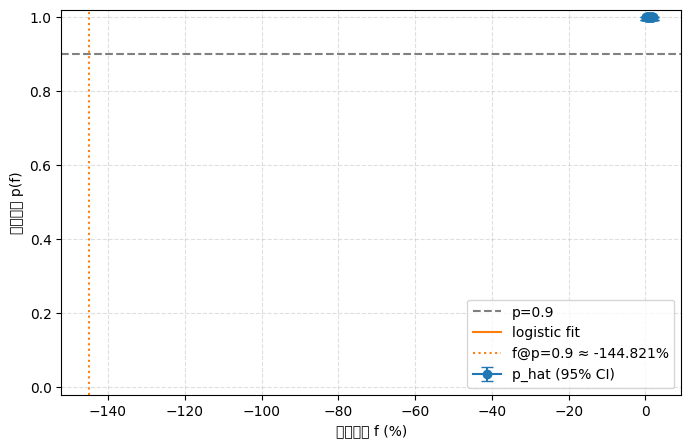

In [10]:
# 修正版 Cell 3: plot p(f) with safe CI handling and logistic fit
import math
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

def logistic(x, a, b):
    return 1.0 / (1.0 + np.exp(-(a + b * x)))

def fit_logistic(fs, phats, weights=None):
    try:
        p0 = [0.0, 50.0]
        popt, pcov = curve_fit(logistic, fs, phats, p0=p0, sigma=weights, maxfev=20000)
        return popt, pcov
    except Exception as e:
        print("logistic fit error:", e)
        return None, None

# load MC CSV (确保 df_mc 已存在)
if 'df_mc' not in globals():
    if mc_csv.exists():
        df_mc = pd.read_csv(mc_csv)
    elif coarse_csv.exists():
        df_mc = pd.read_csv(coarse_csv)
    else:
        raise FileNotFoundError("找不到 monte_carlo_results.csv 或 coarse CSV，请先生成。")

# ensure numeric
for col in ['f', 'p_hat', 'ci_low', 'ci_high']:
    if col not in df_mc.columns:
        raise KeyError(f"结果 CSV 缺少列: {col}")
    df_mc[col] = pd.to_numeric(df_mc[col], errors='coerce')

# drop rows with NaN in these cols
bad_rows = df_mc[df_mc[['f','p_hat','ci_low','ci_high']].isnull().any(axis=1)]
if len(bad_rows) > 0:
    print("Warning: 以下行含 NaN，将被忽略：")
    display(bad_rows)
    df_mc = df_mc.dropna(subset=['f','p_hat','ci_low','ci_high'])

# sort
df_mc = df_mc.sort_values('f').reset_index(drop=True)
fs = df_mc['f'].values
ps = df_mc['p_hat'].values
ci_low = df_mc['ci_low'].values
ci_high = df_mc['ci_high'].values

# Defensive: clip CI into [0,1]
ci_low = np.clip(ci_low, 0.0, 1.0)
ci_high = np.clip(ci_high, 0.0, 1.0)

# Compute asymmetric yerr and ensure non-negative
lower_err = ps - ci_low
upper_err = ci_high - ps

# Find any negative entries (should be very rare)
neg_lower_idx = np.where(lower_err < -1e-12)[0]
neg_upper_idx = np.where(upper_err < -1e-12)[0]
if len(neg_lower_idx) > 0 or len(neg_upper_idx) > 0:
    print("注意：发现下/上误差出现负值（将被裁剪为 0），请检查对应行：")
    if len(neg_lower_idx) > 0:
        print("  下误差负值索引：", neg_lower_idx, "（f,p_hat,ci_low）:")
        display(df_mc.iloc[neg_lower_idx][['f','p_hat','ci_low','ci_high']])
    if len(neg_upper_idx) > 0:
        print("  上误差负值索引：", neg_upper_idx, "（f,p_hat,ci_high）:")
        display(df_mc.iloc[neg_upper_idx][['f','p_hat','ci_low','ci_high']])

# Clip to non-negative
lower_err = np.maximum(lower_err, 0.0)
upper_err = np.maximum(upper_err, 0.0)

# Plot with errorbars
plt.figure(figsize=(8,5))
plt.errorbar(fs*100.0, ps, yerr=[lower_err, upper_err], fmt='o-', capsize=4, markersize=6, label='p_hat (95% CI)')
plt.axhline(0.9, color='gray', linestyle='--', label='p=0.9')

# logistic fit (try)
popt, pcov = fit_logistic(fs, ps)
if popt is not None:
    xs = np.linspace(fs.min(), fs.max(), 300)
    ys = logistic(xs, *popt)
    plt.plot(xs*100.0, ys, '-', label='logistic fit')
    # compute f@p=0.9 if possible
    a, b = popt
    try:
        val = -math.log(1.0/0.9 - 1.0)
        f_at_09 = (val - a) / b
        if np.isfinite(f_at_09):
            plt.axvline(f_at_09*100.0, color='C1', linestyle=':', label=f"f@p=0.9 ≈ {f_at_09*100:.3f}%")
            print("Estimated f@p=0.9 (logistic fit):", f_at_09)
    except Exception as e:
        print("计算 f@p=0.9 失败：", e)

plt.xlabel("体积分数 f (%)")
plt.ylabel("导通概率 p(f)")
plt.ylim(-0.02, 1.02)
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()
plt.show()

# Cell 4：  
最大簇占比（如果有 coarse CSV 或此前计算数据），并把它与 p(f) 并列显示

In [11]:
# Cell 4: plot largest cluster fraction if coarse CSV exists (or compute from monte_carlo if you have per-sample cluster info)
if coarse_csv.exists():
    df_coarse = pd.read_csv(coarse_csv).sort_values('f')
    # common column name might be 'largest_frac' or similar - try to detect
    if 'largest_frac' in df_coarse.columns:
        plt.figure(figsize=(6,4))
        plt.plot(df_coarse['f'].values*100, df_coarse['largest_frac'].values, '-o', label='largest cluster fraction')
        plt.xlabel("体积分数 f (%)")
        plt.ylabel("最大簇占比 (segments)")
        plt.grid(True)
        plt.show()
    else:
        print("coarse CSV present but no 'largest_frac' column. Columns:", df_coarse.columns.tolist())
else:
    print("No coarse CSV found to plot cluster fraction.")

coarse CSV present but no 'largest_frac' column. Columns: ['f', 'N', 'trials', 'successes', 'p_hat', 'ci_low', 'ci_high', 'elapsed_s']


# Cell 5：交互式 sample viewer  
（使用 ipywidgets，让你选择 samples_dir 下的 pickle 文件，然后显示 XY 投影 + 3D，并可滑动 thresh 来动态高亮连接簇）

In [ ]:
# Cell 5: interactive sample viewer (requires ipywidgets)
if not _HAS_WIDGETS:
    print("ipywidgets not available; install it (pip install ipywidgets) to enable interactive sample viewer.")
else:
    pkl_files = sorted([p for p in samples_dir.glob('*.pkl')])
    if not pkl_files:
        print("No sample pickles found in", samples_dir)
    else:
        sel = widgets.Dropdown(options=[str(p.name) for p in pkl_files], description='sample:')
        thresh_slider = widgets.FloatSlider(value=1.8, min=0.0, max=200.0, step=0.5, description='thresh (nm):')
        btn = widgets.Button(description='Show', button_style='primary')
        out = widgets.Output()

        display(widgets.HBox([sel, thresh_slider, btn]), out)

        def on_show(b):
            with out:
                clear_output(wait=True)
                fname = Path(samples_dir) / sel.value
                print("Loading", fname)
                with open(fname, 'rb') as f:
                    obj = pickle.load(f)
                segments = obj.get('segments', [])
                seed = obj.get('seed', None)
                fval = obj.get('f', None)
                print(f"seed={seed}, f={fval}, segments={len(segments)}")
                # compute centers
                centers = np.array([seg.center() for seg in segments])
                xs, ys, zs = centers[:,0], centers[:,1], centers[:,2]

                # compute connectivity at current thresh and get connected cluster roots
                thr = thresh_slider.value
                connected, uf = build_connectivity(segments, L, thr)
                print("connected (left-right):", connected)
                # build roots map
                roots={}
                for i in range(len(segments)):
                    try:
                        roots[i] = uf.find(i)
                    except Exception:
                        # try fallback: treat each index as root
                        roots[i] = i
                # determine clusters that touch left and right
                left_root_set=set(); right_root_set=set()
                for i,s in enumerate(segments):
                    d_left = segment_plane_distance_to_x_plane(s.p0, s.p1, -L/2.0)
                    surf_left = max(0.0, d_left - s.r)
                    if surf_left <= thr + 1e-9:
                        left_root_set.add(roots.get(i, i))
                    d_right = segment_plane_distance_to_x_plane(s.p0, s.p1, L/2.0)
                    surf_right = max(0.0, d_right - s.r)
                    if surf_right <= thr + 1e-9:
                        right_root_set.add(roots.get(i, i))
                spanning_roots = left_root_set & right_root_set
                # pick cluster to highlight: if connected True, pick intersection root; else pick largest root that touches left
                highlight_root = None
                if spanning_roots:
                    highlight_root = next(iter(spanning_roots))
                else:
                    # pick any root in left_root_set
                    if left_root_set:
                        highlight_root = next(iter(left_root_set))
                mask = np.array([roots.get(i,i)==highlight_root for i in range(len(segments))])

                # plot XY
                fig = plt.figure(figsize=(10,4))
                ax1 = fig.add_subplot(1,2,1)
                ax1.scatter(xs[~mask], ys[~mask], s=8, color='blue', alpha=0.4, label='other')
                ax1.scatter(xs[mask], ys[mask], s=12, color='red', alpha=0.9, label='highlight cluster')
                ax1.axvline(-L/2.0, color='k', linestyle='--'); ax1.axvline(L/2.0, color='k', linestyle='--')
                ax1.set_title(f"XY seed={seed} thr={thr}")
                ax1.set_xlabel('X'); ax1.set_ylabel('Y'); ax1.set_aspect('equal', 'box')
                ax1.legend()

                # 3D
                ax2 = fig.add_subplot(1,2,2, projection='3d')
                ax2.scatter(xs[~mask], ys[~mask], zs[~mask], s=6, color='lightgray', alpha=0.5)
                ax2.scatter(xs[mask], ys[mask], zs[mask], s=12, color='red', alpha=0.9)
                ax2.set_title('3D view')
                ax2.set_xlabel('X'); ax2.set_ylabel('Y'); ax2.set_zlabel('Z')
                plt.show()

        btn.on_click(on_show)

Output()

# Cell 6：把关键图保存并输出文件名  
（用于论文直接引用）

ValueError: 'yerr' must not contain negative values

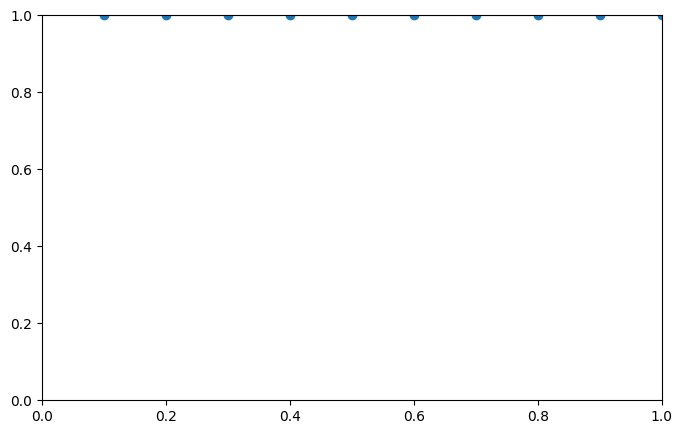

In [13]:
# Cell 6: save main pf plot and sample images (non-interactive save helper)
figures_dir = Path(repo_root) / 'figures'
figures_dir.mkdir(parents=True, exist_ok=True)

# reuse the p(f) plotting code but save to files
if 'df_mc' in globals():
    out_svg = figures_dir / 'pf_curve.svg'
    out_png = figures_dir / 'pf_curve.png'
    plt.figure(figsize=(8,5))
    plt.errorbar(df_mc['f'].values*100, df_mc['p_hat'].values, yerr=[df_mc['p_hat']-df_mc['ci_low'], df_mc['ci_high']-df_mc['p_hat']], fmt='o-', capsize=4)
    plt.axhline(0.9, color='gray', linestyle='--')
    if popt is not None:
        xs = np.linspace(df_mc['f'].min(), df_mc['f'].max(), 300)
        ys = logistic(xs, *popt)
        plt.plot(xs*100, ys, '-', label='logistic fit')
    plt.xlabel("体积分数 f (%)")
    plt.ylabel("导通概率 p(f)")
    plt.ylim(-0.02, 1.02)
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.savefig(out_svg)
    plt.savefig(out_png, dpi=300)
    print("Saved pf curve to", out_svg, out_png)
else:
    print("df_mc not found, cannot save pf plot.")